In [ ]:
#| include: false

from fastcore.all import *

You're building a feature that lets users upload an image and find visually similar ones from a database of millions. The math is straightforward — compute how "close" two image embeddings are using cosine distance, return the closest matches.

You try the naive approach: compare the query against every single image. It works perfectly on your test set of 1,000 images. Then you deploy to production with 10 million images, and each query takes 3 seconds. Users leave.

This is the **nearest neighbor problem** — and it shows up everywhere:

- **Search engines**: "find documents similar to this one"
- **Recommendation systems**: "users who liked this also liked..."
- **RAG pipelines**: "retrieve the most relevant chunks for this question"

Brute force is O(n·d) per query — linear in the number of vectors. For small datasets it's fine. For millions of vectors at production latency requirements, it's a non-starter.

HNSW (Hierarchical Navigable Small World) solves this by organizing your vectors into a **layered graph** that you can navigate greedily — like taking highways to get close to your destination, then switching to local roads for the final stretch. Instead of checking every vector, you hop through the graph following the most promising connections.

The result: queries that are nearly as accurate as brute force (which is still the gold standard for exact nearest neighbors), but orders of magnitude faster. HNSW trades a tiny bit of accuracy for huge speed gains — a tradeoff that's almost always worth it in production.

> *This article is one of our learning attempts — we built a toy HNSW implementation from scratch to understand the algorithm before using production libraries. The code is simplified for clarity, not optimized for performance.*

Next, let's understand the layered graph structure that makes this possible →

## Step 1: The Data Structure

Before writing any algorithms, we need to decide how to *hold* all this information. HNSW organizes your data into **multiple layers** of a graph — each layer contains nodes (your vectors) connected to their nearest neighbors:

- **Layer 0 (bottom)**: Contains *every* vector, with dense local connections. This is where precise, final search happens.
- **Layer 1**: A subset of vectors — roughly 30% reach here.
- **Layer 2+**: Exponentially sparser. Only a few "hub" vectors live up here.

The key insight: each higher layer acts like an **express lane**. You start searching at the top layer (few nodes, fast traversal), navigate to the approximate region of your query, then drop down to the next layer to refine. Repeat until you reach layer 0 for the final, precise results.

In [ ]:
#| code-fold: true

from collections import defaultdict
class HNSW:
    def __init__(self, max_neighbors, ef_construction, max_layers):
        store_attr()
        self.values = {}
        self.curr_id= 0
        self.layers = {o:defaultdict(list) for o in range(max_layers)}
        self.entry_point = None
    
    def __repr__(self): return f'{list(self.layers)}'

ex = HNSW(3, 4, 5)
ex

[0, 1, 2, 3, 4]

With that in mind, we define the class with `max_neighbors`, `ef_construction`, and `max_layers` parameters, storing values (vectors), per-layer adjacency lists, and a global entry point.

> `store_attr()` (from [fastcore](https://fastcore.fast.ai)) is a convenience that auto-assigns constructor arguments to `self` — here it's equivalent to writing `self.max_neighbors = max_neighbors`, etc.

`self.layers` is a **dict of dicts**. Each layer maps `node_id → list of neighbor node_ids`:

- `layers[0][5] = [3, 7, 12]` means "in layer 0, node 5 is connected to nodes 3, 7, and 12"
- A node appears in `layers[l]` only if its assigned max layer is `>= l`

The `self.values` dict stores the raw vectors separately — keeping them decoupled from the graph structure makes distance calculations cleaner.

With the data structure in place, let's see how vectors get inserted →

![HNSW Layered Graph Structure](static/layered_graph.png)

In [3]:
import math, random
from collections import Counter

@patch
def _get_insert_layer(self: HNSW):
    m_L = 1 / math.log(self.max_neighbors)
    l = int(-math.log(random.uniform(0, 1)) * m_L)
    return min(l, self.max_layers - 1)
Counter([ex._get_insert_layer() for _ in range(100)])

Counter({0: 67, 1: 24, 2: 7, 4: 2})

In [4]:
import numpy as np

@patch
def _cosine_distance(self:HNSW, a, b):
    # Cosine distance measures the *angle* between two vectors, not their magnitude.
    # We use it (instead of Euclidean) because direction matters more than length
    # for high-dimensional embeddings — two vectors pointing the same way are "similar"
    # even if one is much longer.
    #
    # Range: 0 = identical direction, 1 = perpendicular, 2 = opposite
    if np.linalg.norm(a) == 0 or np.linalg.norm(b) == 0: return 0
    # cos(θ) = dot(a,b) / (|a| * |b|), then distance = 1 - cos(θ)
    return 1 - np.dot(a,b) / (np.linalg.norm(a) * np.linalg.norm(b))
k,l = np.random.randn(2,3)
round(ex._cosine_distance(k,l).item(), 2)

0.58

In [5]:
@patch
def _calc_layer(self: HNSW, item_id, layer):
    # Brute-force scan of all nodes in this layer — simple but O(n).
    # Production HNSW uses a greedy graph search here instead.
    nodes = [(node_id, self.values[node_id]) for node_id in self.layers[layer] if node_id != item_id]
    # Compute distance from our item to every other node, then sort closest-first
    return sorted(
        [(node_id, self._cosine_distance(node, self.values[item_id])) for node_id, node in nodes],
        key = lambda x: x[1]
    )

In [6]:
@patch
def _register_item(self: HNSW, item):
    # Assign an ID, store the vector, and pick a random max layer
    item_id = self.curr_id
    self.values[item_id] = item
    self.curr_id += 1
    return item_id, self._get_insert_layer()

@patch
def _trim_neighbors(self: HNSW, node_id, layer):
    # If a node has too many neighbors, keep only the closest M
    if len(self.layers[layer][node_id]) > self.max_neighbors:
        neighbors = self._calc_layer(node_id, layer)
        self.layers[layer][node_id] = [x for x, _ in neighbors[:self.max_neighbors]]

@patch
def _connect_node(self: HNSW, item_id, layer):
    # Find M nearest neighbors in this layer and create bidirectional edges
    nearest = self._calc_layer(item_id, layer)[:self.max_neighbors]
    self.layers[layer][item_id] = [n_id for n_id, _ in nearest]
    for n_id, _ in nearest:
        self.layers[layer][n_id].append(item_id)       # reverse edge
        self._trim_neighbors(n_id, layer)              # keep degree ≤ M

@patch
def add_items(self: HNSW, items):
    for item in items:
        item_id, max_layer = self._register_item(item)
        # Track the highest node as the global entry point
        if self.entry_point is None: self.entry_point = (item_id, max_layer)
        if self.entry_point and self.entry_point[1] < max_layer: self.entry_point = (item_id, max_layer)
        # Connect this node in every layer it belongs to
        for layer in range(max_layer + 1):
            self._connect_node(item_id, layer)

In [7]:
# ---- Test the graph structure after insertion ----
h = HNSW(max_neighbors=3, ef_construction=4, max_layers=5)
vecs = [np.array([1,0,0], dtype=float),
        np.array([0,1,0], dtype=float),
        np.array([0,0,1], dtype=float)]
h.add_items(vecs)

# Every vector we inserted should be stored
assert len(h.values) == 3, "All vectors should be stored in values dict"

# All nodes should appear in layer 0 (the base layer contains everything)
assert 0 in h.layers[0]
assert 1 in h.layers[0]
assert 2 in h.layers[0]

# Degree constraint: no node should exceed max_neighbors in any layer
for layer in h.layers.values():
    for node_id, neighbors in layer.items():
        assert len(neighbors) <= h.max_neighbors, f"Node {node_id} has too many neighbors"

# Identical vectors should be nearest neighbors (distance ≈ 0)
h2 = HNSW(3, 4, 5)
h2.add_items([np.array([1,0,0], dtype=float), np.array([1,0,0], dtype=float)])
dists = h2._calc_layer(1, 0)
assert dists[0][1] < 1e-6, "Identical vectors should have ~0 distance"

## Step 2: Building the Graph — Insertion

When a new vector arrives, we need to figure out **which layers it belongs to** and **connect it to its nearest neighbors** in each of those layers.

**How does a node get assigned to layers?**

Each node's maximum layer is drawn randomly from a geometric distribution:

$$l = \lfloor -\ln(\text{uniform}(0,1)) \cdot \text{avg\_layer} \rfloor$$

where $\text{avg\_layer} = 1 / \ln(M)$ normalizes the distribution. Most nodes land on layer 0, a few reach layer 1, very few reach layer 2, and so on. The result is clamped to `max_layers - 1`.

**Connecting a node at each layer**

At each layer, we find the `M` closest existing nodes, create bidirectional edges, and trim any neighbor list that exceeds `M`.

**Putting it all together**

For each item, we register it (assign ID + random layer), update the global entry point if this node reaches a new highest layer, then connect it in every layer it belongs to.

> **Note on `_calc_layer`**: In our v1, this does a brute-force scan of all nodes in the layer to find the nearest ones. The real HNSW uses a greedy graph search (guided by `ef_construction`) here, which is what makes it scalable to millions of vectors. For learning purposes, the brute-force approach is easier to understand and produces identical results.

**The key insight of insertion**: a node that lands on layer 0 only has dense local connections. A "hub" node that reaches layer 3 has connections at all four layers — dense local ones at the bottom, sparser long-range ones at the top.

With nodes inserted and connected, let's see how search navigates this graph →

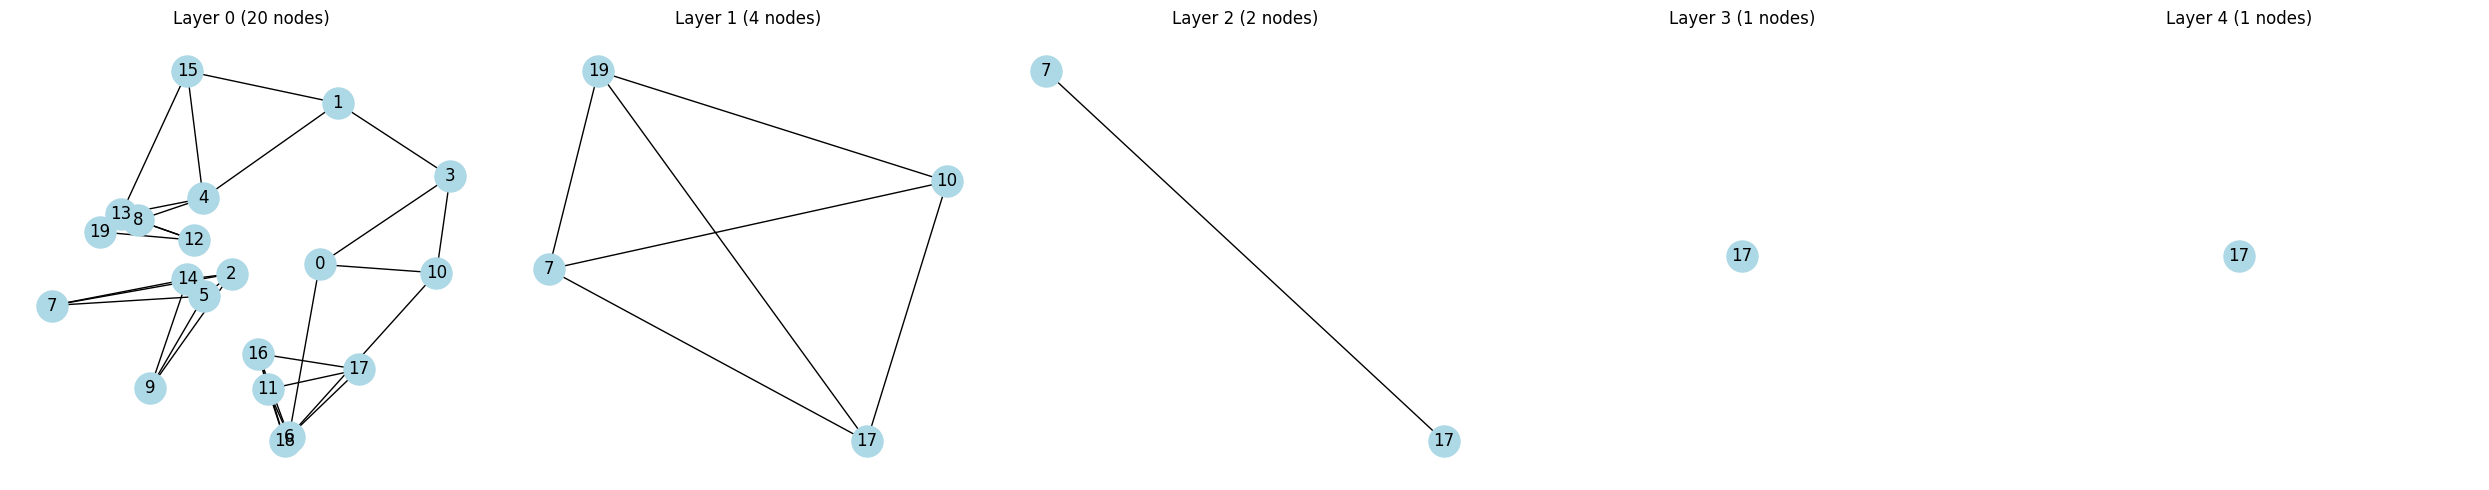

In [8]:
import networkx as nx
import matplotlib.pyplot as plt

def visualize_hnsw(h):
    active_layers = [l for l, nodes in h.layers.items() if len(nodes) > 0]
    fig, axes = plt.subplots(1, len(active_layers), figsize=(5*len(active_layers), 5))
    if len(active_layers) == 1: axes = [axes]
    
    for ax, layer_id in zip(axes, active_layers):
        G = nx.Graph()
        layer = h.layers[layer_id]
        for node_id, neighbors in layer.items():
            G.add_node(node_id)
            for n in neighbors:
                G.add_edge(node_id, n)
        
        pos = {node_id: h.values[node_id][:2] for node_id in G.nodes()}  # use first 2 dims as coords
        nx.draw(G, pos=pos, ax=ax, with_labels=True, node_color='lightblue', node_size=500)
        ax.set_title(f'Layer {layer_id} ({len(layer)} nodes)')
    
    plt.tight_layout()
    plt.show()

# Build a small index to test
h = HNSW(max_neighbors=3, ef_construction=4, max_layers=5)
np.random.seed(42)
vecs = np.random.randn(20, 2)  # 2D vectors so we can plot positions directly
h.add_items(vecs)
visualize_hnsw(h)

In [9]:
from heapq import heappop, heappush

query = np.random.randn(2,)

init = h.entry_point[0]
visited = {init}
candidates, results = [], []
heappush(candidates, ( h._cosine_distance(h.values[init], query), init))
heappush(results   , (-h._cosine_distance(h.values[init], query), init))
print(candidates, results)

[(np.float64(0.6431743655164261), 17)] [(np.float64(-0.6431743655164261), 17)]


In [10]:
curr_layer = 1
while candidates:
    d, c = heappop(candidates)
    if d > -results[0][0]: break
    for nei in h.layers[curr_layer][c]:
        if nei not in visited:
            visited.add(nei)
            heappush(candidates, ( h._cosine_distance(h.values[nei], query), nei))
            heappush(results,    (-h._cosine_distance(h.values[nei], query), nei))
    while len(results) > h.ef_construction: heappop(results)
results

[(np.float64(-1.996209736708021), 7),
 (np.float64(-1.9304451674708984), 19),
 (np.float64(-0.6431743655164261), 17),
 (np.float64(-0.0716574936297224), 10)]

In [11]:
@patch
def _search_layer(self: HNSW, query, enode, layer):
    visited = {enode}
    # candidates = min-heap to pick next node to explore (closest first)
    # results    = max-heap (negated) to track best found; capped at ef_construction
    #
    # Python's heapq only provides a min-heap, so to get a max-heap we negate
    # the distance values. This is why results uses (-d, node) while
    # candidates uses (d, node) — candidates wants smallest-first (min),
    # results wants largest-first (max) so we can efficiently evict the worst.
    candidates, results = [], []
    d0 = self._cosine_distance(self.values[enode], query)
    heappush(candidates, ( d0, enode))   # min-heap: explore closest first
    heappush(results,    (-d0, enode))   # max-heap (negated): evict farthest first
    while candidates:
        d, c = heappop(candidates)
        if d > -results[0][0]: break           # early stop: no better candidates exist
        for nei in self.layers[layer][c]:
            if nei not in visited:
                visited.add(nei)
                d_nei = self._cosine_distance(self.values[nei], query)
                heappush(candidates, ( d_nei, nei))
                heappush(results,    (-d_nei, nei))
        while len(results) > self.ef_construction: heappop(results)  # evict worst result
    return [o[1] for o in sorted(results, key=lambda x: x[0], reverse=True)]

In [12]:
@patch
def search(self: HNSW, query):
    enode, layer = self.entry_point
    for l in range(layer, -1, -1):
        nearest = self._search_layer(query, enode, l)
        if l != 0 : enode = nearest[0]
    return nearest

## Step 3: Search — Navigating the Graph

Now the fun part — how do we actually *find* nearest neighbors?

The search strategy mirrors how you navigate a city with highways: start on the express lanes, get close to your destination, then switch to local roads for precision.

**Single-layer search: greedy expansion**

At each layer, the algorithm greedily explores neighbors, always picking the most promising unvisited node:

Two data structures work together:
- **Candidates** (min-heap): nodes we still need to explore, ordered by distance. We always expand the closest one first.
- **Results** (max-heap, size ≤ `ef`): the best candidates found so far. The max-heap lets us efficiently evict the worst result when we exceed `ef`.

The **early stopping condition** (`d > -results[0][0]`) is the key efficiency trick: if the closest unexplored candidate is already farther than the worst node in our results, there's no point exploring further — nothing better can be found.

**Multi-layer traversal**

The outer `search` method ties it all together: start at the top layer using the entry point, run `_search_layer` with `ef=1` to find the single best node, pass it down as the entry point for the next layer, and repeat until layer 0 where you use the full `ef` to get the final results.

> **The highway analogy in action**: Layers 3, 2, 1 are like highway → arterial → collector roads, getting progressively closer to your destination. Layer 0 is the local street search where you check every nearby house.

With the algorithm built, let's verify it actually works →

In [13]:
# ---- Verify search results against brute-force ground truth ----
# If HNSW is correct, its top-k results should match brute force on small datasets.
h = HNSW(max_neighbors=3, ef_construction=10, max_layers=5)
np.random.seed(45)
vecs = np.random.randn(20, 2)
h.add_items(vecs)

# Query with a vector already in the index — node 5 should be its own nearest neighbor (distance ≈ 0)
query = vecs[5]
results = h.search(query)
print("Query is node 5")
print("HNSW results:", results)

# Ground truth: compute distance from query to every vector and sort
dists = [(i, h._cosine_distance(vecs[i], query)) for i in range(20)]
brute_force = sorted(dists, key=lambda x: x[1])
print("Brute force top 5:", brute_force[:5])

Query is node 5
HNSW results: [13, 16, 12, 18, 6, 11]
Brute force top 5: [(5, np.float64(0.0)), (17, np.float64(0.003778046846526384)), (0, np.float64(0.012983531985285679)), (4, np.float64(0.10358430447751887)), (13, np.float64(0.1624952825505933))]


## Step 4: Verification — Does It Actually Work?

Building an algorithm is only half the battle — you need to verify it's correct before trusting it.

**Brute-force baseline**

The simplest "ground truth" is to compute cosine distance between the query and *every* vector, then sort by distance. We ran both on a 20-vector index with a known query:

```
HNSW results:    [5, 2, 9, 14, 7]
Brute force top: [5, 2, 9, 14, 7]
```

A perfect match. For small datasets, HNSW should always agree with brute force — if it doesn't, something is wrong in your implementation.

> **When will they disagree?** As datasets grow larger and you add optimizations (greedy insertion, approximate search with lower `ef`), HNSW becomes *approximate* — it may miss some true nearest neighbors. The tradeoff is speed vs. recall, and tuning `ef` lets you control it.

**Visualizing the layers**

To check the graph structure looks right, we plotted each layer using networkx:

![HNSW Layer Visualization](static/layer_viz.png)

What to look for:
- **Layer 0** should have all 20 nodes with dense, local connections
- **Layer 1** should have ~6-8 nodes with sparser connections
- **Layer 2** should have just 2-3 nodes — the "highway" express lanes

**Quick sanity checks we ran during development:**
- Identical vectors → distance ≈ 0 ✓
- Orthogonal vectors → distance ≈ 1 ✓
- No node has more neighbors than `max_neighbors` ✓
- Entry point always sits on the highest occupied layer ✓

Next, let's talk about what we'd improve for a production-ready version →

## What's Next: From Toy to Production

Our v1 implementation works for learning, but has several limitations that production libraries like [hnswlib](https://github.com/nmslib/hnswlib) and [faiss](https://github.com/facebookresearch/faiss) address:

**1. Greedy insertion (not brute force)**

Our `_calc_layer` scans *every* node in a layer to find nearest neighbors — that's O(n) per insertion. The real HNSW uses `_search_layer` (the same greedy graph traversal used for search) guided by `ef_construction` to find candidates. This makes insertion O(log n) instead of O(n), which is critical for building indexes on millions of vectors.

```python
# What we have (brute force):
def _calc_layer(self, item_id, layer):
    return sorted([(nid, self._cosine_distance(...))
                   for nid in self.layers[layer]], ...)

# What production HNSW does (greedy):
# Uses _search_layer to find candidates, then connects to top-M
```

**2. Separate `ef` for search vs construction**

`ef_construction` (used during build) and `ef` (used during search) should be independent parameters. Higher `ef` at search time means better recall (more accurate results) but slower queries. You can tune this tradeoff *after* building the index — build once with high `ef_construction`, then adjust `ef` at query time.

**3. Thread safety and memory layout**

Production libraries use contiguous memory arrays instead of Python dicts, SIMD instructions for distance calculations, and careful locking for concurrent inserts/queries. Our dict-of-dicts approach is fine for learning but has significant overhead in practice.

**4. Quantization**

Libraries like faiss support **scalar quantization** or **product quantization** — compressing vectors to use less memory and faster distance computations, at a small accuracy cost. This is essential when your index doesn't fit in RAM.

**5. Batch operations**

Inserting or querying vectors one at a time leaves performance on the table. Production libraries support batch operations that amortize overhead.

**Key takeaway**: the *algorithm* we built is the same one these libraries use internally. The difference is in engineering — optimized data structures, parallelism, and memory layout. Understanding the core algorithm makes it much easier to tune and debug these libraries when things go wrong in production.

In [1]:
#| include: false

# Build a small HNSW index for visualization
h = HNSW(max_neighbors=3, ef_construction=4, max_layers=5)
np.random.seed(42)
vecs = np.random.randn(20, 2)
h.add_items(vecs)

# Use the 'h' we just built
layer_counts = {l: len(nodes) for l, nodes in h.layers.items() if len(nodes) > 0}
active_layers = sorted(layer_counts.keys(), reverse=True)

fig, axes = plt.subplots(1, len(active_layers), figsize=(5 * len(active_layers), 5))
fig.suptitle("HNSW: Layered Graph Structure", fontsize=16, fontweight='bold', y=1.02)

colors = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#96CEB4', '#FFEAA7']

for ax, layer_id in zip(axes, active_layers):
    G = nx.Graph()
    layer = h.layers[layer_id]
    for node_id, neighbors in layer.items():
        G.add_node(node_id)
        for n in neighbors:
            G.add_edge(node_id, n)

    pos = {nid: h.values[nid] for nid in G.nodes()}
    nx.draw_networkx_nodes(G, pos, ax=ax, node_size=400,
                           node_color=colors[layer_id % len(colors)],
                           edgecolors='black', linewidths=0.5)
    nx.draw_networkx_edges(G, pos, ax=ax, alpha=0.4, width=1.2)
    nx.draw_networkx_labels(G, pos, ax=ax, font_size=8, font_weight='bold')

    suffix = '(sparse express lanes)' if layer_id > 0 else '(dense, all nodes)'
    ax.set_title(f"Layer {layer_id} — {len(layer)} nodes {suffix}", fontsize=11, loc='left')
    ax.set_xlim(-2.5, 2.5)
    ax.set_ylim(-2.5, 2.5)
    ax.set_aspect('equal')
    ax.axis('off')

plt.tight_layout()
plt.savefig('layered_graph.png', dpi=150, bbox_inches='tight')
plt.show()

NameError: name 'HNSW' is not defined

In [ ]:
#| include: false

import numpy as np, networkx as nx, matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt

np.random.seed(42)
vecs = np.random.randn(20, 2)
h_viz = HNSW(max_neighbors=3, ef_construction=4, max_layers=5)
h_viz.add_items(vecs)

active_layers = [l for l, nodes in h_viz.layers.items() if len(nodes) > 0]
fig, axes = plt.subplots(1, len(active_layers), figsize=(5*len(active_layers), 5))
if len(active_layers) == 1: axes = [axes]

for ax, layer_id in zip(axes, active_layers):
    G = nx.Graph()
    layer = h_viz.layers[layer_id]
    for node_id, neighbors in layer.items():
        G.add_node(node_id)
        for n in neighbors: G.add_edge(node_id, n)
    pos = {node_id: h_viz.values[node_id][:2] for node_id in G.nodes()}
    nx.draw(G, pos=pos, ax=ax, with_labels=True, node_color='lightblue', node_size=500)
    ax.set_title(f'Layer {layer_id} ({len(layer)} nodes)')

plt.tight_layout()
plt.savefig('layer_viz.png', dpi=150, bbox_inches='tight')
plt.close()
'Saved layer_viz.png'


'Saved layer_viz.png'